# Project 4: Pneumonia Detection from Chest X-rays

## Problem Statement
Develop a deep learning model to detect pneumonia from chest X-ray images. The system should classify images into normal and pneumonia classes.

## Objectives
- Medical image classification
- Use advanced CNN like DenseNet121
- Understand healthcare AI applications


# Step 1: Import Required Libraries

## Description
In this step, all the required libraries for deep learning, image processing, dataset handling, evaluation, and visualization are imported.


In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix


# Step 2: Download Dataset from Google Drive

## Description
Download and extract the dataset from Google Drive during runtime.


In [2]:
DATASET_URL = "https://drive.google.com/file/d/1cPIN8ZE9rcwjsv9-TTVH3r6ZraJAA3rj/view?usp=sharing"
ZIP_FILE_NAME = "chest_xray_dataset.zip"
EXTRACT_PATH = "dataset"

!gdown --fuzzy "$DATASET_URL" -O "$ZIP_FILE_NAME"

with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset downloaded and extracted successfully.")

Downloading...
From (original): https://drive.google.com/uc?id=1cPIN8ZE9rcwjsv9-TTVH3r6ZraJAA3rj
From (redirected): https://drive.google.com/uc?id=1cPIN8ZE9rcwjsv9-TTVH3r6ZraJAA3rj&confirm=t&uuid=784a02ad-bb0d-4afa-bb34-357705650e6d
To: /content/chest_xray_dataset.zip
100% 2.46G/2.46G [00:40<00:00, 60.9MB/s]
Dataset downloaded and extracted successfully.


# Step 3: Explore Dataset

Explore dataset folders and count images in each class.


In [3]:
train_normal_path = os.path.join(EXTRACT_PATH, 'chest_xray/train/NORMAL')
train_pneumonia_path = os.path.join(EXTRACT_PATH, 'chest_xray/train/PNEUMONIA')

test_normal_path = os.path.join(EXTRACT_PATH, 'chest_xray/test/NORMAL')
test_pneumonia_path = os.path.join(EXTRACT_PATH, 'chest_xray/test/PNEUMONIA')

print("Training NORMAL Images:", len(os.listdir(train_normal_path)))
print("Training PNEUMONIA Images:", len(os.listdir(train_pneumonia_path)))
print("Testing NORMAL Images:", len(os.listdir(test_normal_path)))
print("Testing PNEUMONIA Images:", len(os.listdir(test_pneumonia_path)))


Training NORMAL Images: 1341
Training PNEUMONIA Images: 3875
Testing NORMAL Images: 234
Testing PNEUMONIA Images: 390


# Step 4: Visualize Sample Images

Sample chest X-ray images from both classes are displayed in this step. This helps in visually understanding the difference between NORMAL and PNEUMONIA X-rays.


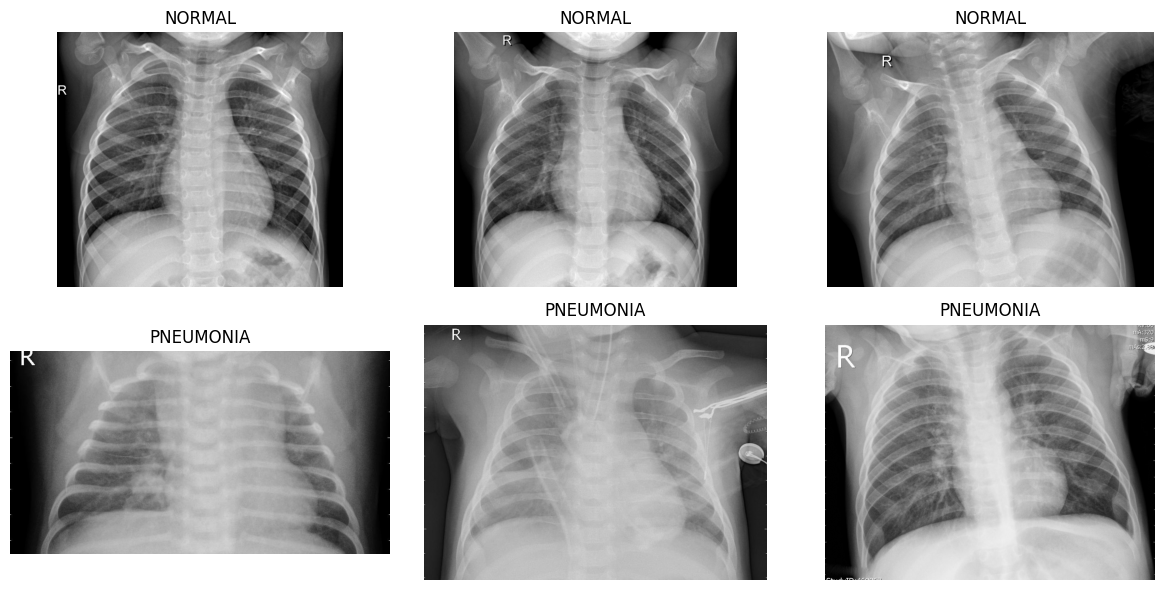

In [4]:
normal_images = os.listdir(train_normal_path)
pneumonia_images = os.listdir(train_pneumonia_path)

plt.figure(figsize=(12, 6))

for i in range(3):
    img = Image.open(os.path.join(train_normal_path, normal_images[i]))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title('NORMAL')
    plt.axis('off')

for i in range(3):
    img = Image.open(os.path.join(train_pneumonia_path, pneumonia_images[i]))
    plt.subplot(2, 3, i + 4)
    plt.imshow(img, cmap='gray')
    plt.title('PNEUMONIA')
    plt.axis('off')

plt.tight_layout()
plt.show()


# Step 5: Data Preprocessing

In this step, image preprocessing and augmentation are performed. Images are resized, normalized, and augmented to improve model generalization and reduce overfitting.


In [5]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(EXTRACT_PATH, 'chest_xray/train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(EXTRACT_PATH, 'chest_xray/val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(EXTRACT_PATH, 'chest_xray/test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Step 6: Build DenseNet121 Model

DenseNet121 is used as the base transfer learning model with pre-trained ImageNet weights. Additional layers are added for binary classification between NORMAL and PNEUMONIA classes.


In [6]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

# Step 7: Train the Model

The model is trained using the training dataset and validated on validation data. EarlyStopping and ReduceLROnPlateau are used to improve training performance and prevent overfitting.


In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 732ms/step - accuracy: 0.7945 - loss: 0.4513 - val_accuracy: 0.8125 - val_loss: 0.4763 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 654ms/step - accuracy: 0.8738 - loss: 0.2972 - val_accuracy: 0.8125 - val_loss: 0.4741 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 616ms/step - accuracy: 0.8834 - loss: 0.2689 - val_accuracy: 0.6875 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.8961 - loss: 0.2473 - val_accuracy: 0.8750 - val_loss: 0.4181 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.8992 - loss: 0.2429 - val_accuracy: 0.8750 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.9061 - loss: 0.2282 - val_accuracy: 0.8750 - val_loss: 0.3868 - learning_rate: 0.0010
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 612ms/step - accura

# Step 8: Evaluate Model Performance

This step evaluates the trained model on unseen test data. The final test accuracy and loss values help measure how well the model performs.


In [8]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.8686 - loss: 0.3068
Test Loss: 0.30683422088623047
Test Accuracy: 0.8685897588729858


# Step 9: Plot Accuracy and Loss Graphs

Training and validation accuracy/loss graphs are plotted in this step. These graphs help analyze the learning performance of the model during training.


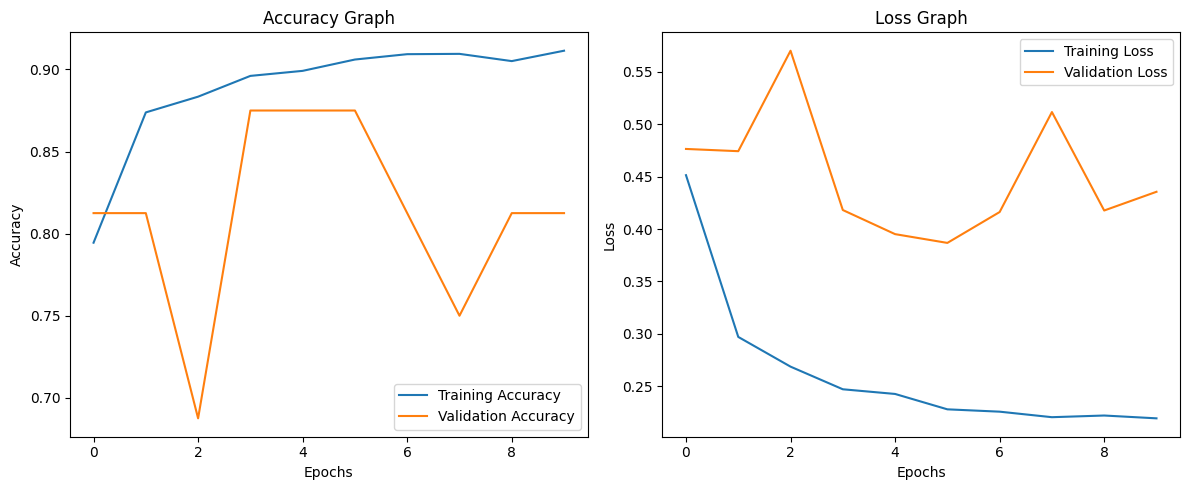

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Step 10: Generate Classification Report

A classification report is generated to evaluate precision, recall, and F1-score. These metrics provide detailed insight into the model's classification performance.


In [10]:
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print(report)


20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 829ms/step
              precision    recall  f1-score   support

      NORMAL       0.89      0.74      0.81       234
   PNEUMONIA       0.86      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.87       624



# Step 11: Create Confusion Matrix

The confusion matrix visualizes correct and incorrect predictions made by the model. It helps identify how many images were classified correctly or incorrectly.


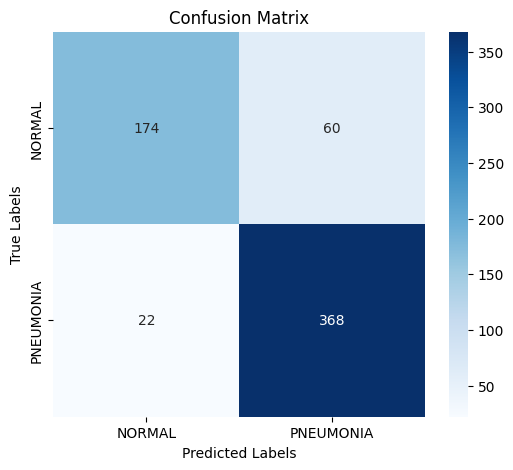

In [11]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


# Step 12: Visualize Predictions

This step tests the trained model on actual chest X-ray images from the test dataset. The model prediction and actual label are displayed together to visually verify prediction performance.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


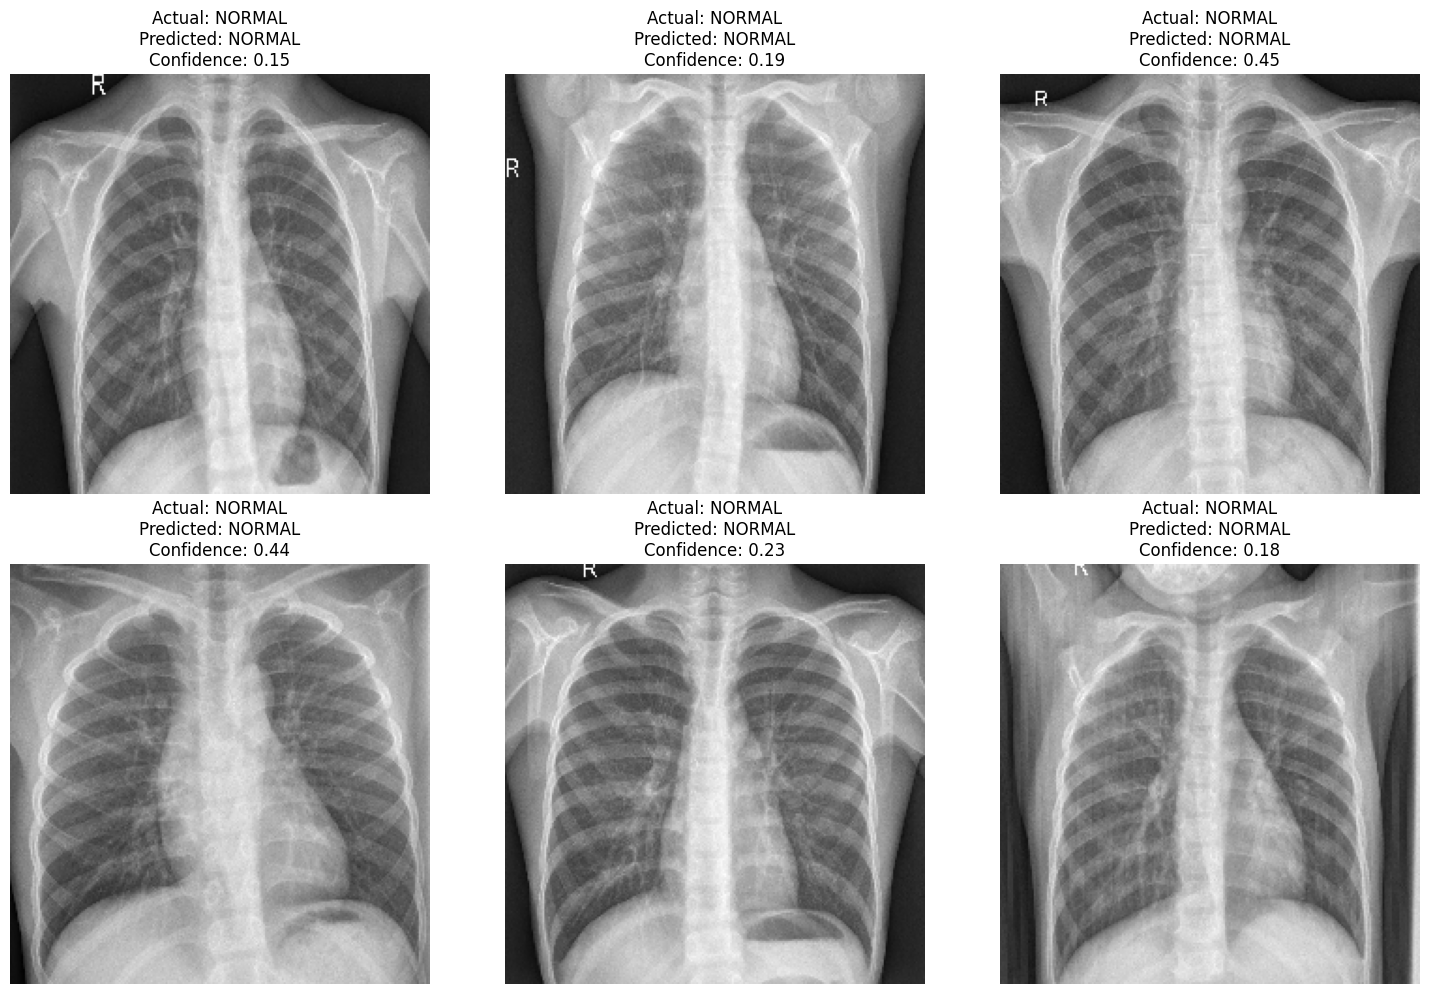

In [12]:
sample_images, sample_labels = next(test_generator)
predictions = model.predict(sample_images)

plt.figure(figsize=(15, 10))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])

    confidence = float(predictions[i][0])

    predicted_label = 'PNEUMONIA' if confidence > 0.5 else 'NORMAL'
    actual_label = 'PNEUMONIA' if sample_labels[i] == 1 else 'NORMAL'

    plt.title(
        f'Actual: {actual_label}\n'
        f'Predicted: {predicted_label}\n'
        f'Confidence: {confidence:.2f}'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()


# Step 13: Save the Trained Model


### Explanation
The trained DenseNet121 model is saved into an H5 file format. This allows the model to be reused later without retraining.


In [13]:
model.save('pneumonia_detection_model.h5')

print("Model saved successfully.")


Model saved successfully.
